# Thesis proposal: how many attention heads does a task need?

**The question.** Can a model find, during one training run, how many attention heads a
task needs and which ones they are?

**The idea.** Borrow the rules the brain's blood supply uses to share a limited resource:
feedback on need, local sensing, tolerance to losing a vessel when neighbours can cover it,
and pruning of vessels that carry little flow. Turn each rule into a mechanism, and **keep
only the ones that survive a test where they are removed**.

**What the preliminary results show** (every number below is computed from the runs):

1. A task where the right answer is known, and a simple algebra reason for that answer:
   each head is one equation, and $R$ unknowns need $R$ different equations.
2. Rules that only look at how heads compare with each other cannot count heads. Rules that
   check the loss can.
3. The ingredient that works is the **collateral** rule: a head is worth what *no other head
   can cover*. Removing it breaks the count or the stability.
4. The **fixed total** (the autoregulation analogy) does *not* earn its place. Without it
   the count is exact and compute is slightly lower.
5. On a second task the collateral rule works at one setting and fails at another.

**What I propose** (Section 9): finish the theory of the benchmark, establish the collateral
rule with enough seeds and a harder task, and test a prediction from vascular network
physics: *when does a circuit stay minimal, and when does it keep backup heads?*

| section | contents |
|---|---|
| 1 | the question in plain words, and the biology used as a design source |
| 2 | what already exists |
| 3 | the task, and why it needs exactly $R$ heads (experiment E1) |
| 4 | which rules can count heads |
| 5 | does each piece of biology earn its place? (experiment E3) |
| 6 | planted copies (experiment E4) |
| 7 | compute: one run against searching over sizes |
| 8 | a second task (experiment E2) |
| 9 | the proposal: aims, predictions, and what would prove me wrong |
| 10 | how to reproduce everything |

In [1]:
import glob, pickle, sys
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

sys.path.insert(0, "../src")
from hemo.config import Cfg

BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
GREY, INK, DARK = "#9c9a93", "#52514e", "#0b0b0b"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": GREY, "axes.titlelocation": "left", "axes.titlesize": 10,
                     "axes.titleweight": "bold", "legend.frameon": False, "font.size": 9})


def load(pattern):
    runs = []
    for path in sorted(glob.glob(pattern)):
        with open(path, "rb") as f:
            r = pickle.load(f)
        if isinstance(r, dict) and "cfg" in r and "hist" in r:
            runs.append(r)
    return runs


RUNS = load("../results/*.pkl") + load("../results/proposal/*.pkl")
QSA_FIX = load("../results/qsa_fix/*.pkl")
print(f"{len(RUNS)} training runs, plus {len(QSA_FIX)} runs of the fair qsa_cross re-test")

533 training runs, plus 12 runs of the fair qsa_cross re-test


In [2]:
DEFAULT = Cfg()


def setting(run, key):
    # older runs predate some options; they used the default
    return run["cfg"].get(key, getattr(DEFAULT, key))


# pick() pins every option any experiment varied, so one arm's runs never leak into another
MAIN = dict(task="multi_relation", steps=4000, d_k=32, demand="outnorm_ema", kappa_end=1.5,
            target_frac=0.02, delay=0, pool_beta=0.0, leak=0.0, n_territories=8,
            stall_gate=0.0, autoreg_gain=0.003, precondition=0.0, flow_exponent=4.0,
            price_frac=0.01, probe_every=25, taper=0, budget_hold_frac=0.25, prune_stop=1,
            conserve=1, local_value="refit", plant_copies=0)


def pick(**want):
    want = {**MAIN, **want}
    return [r for r in RUNS if all(setting(r, k) == v for k, v in want.items())]


def heads_kept(run):
    # median number of heads switched on over the last part of training
    ledger = run["hist"]["ledger"]
    start = int((setting(run, "budget_hold_frac") + setting(run, "budget_anneal_frac")) * len(ledger))
    return float(np.median((ledger[start:] > 1e-9).sum(axis=1)))


def solved(run):
    # the bar: final loss within 2% of the loss of a model that learned nothing
    return run["final_loss"] <= 0.02 * run["trivial"]


def worst_after_solved(run):
    # highest loss after the run first got under the bar, as a multiple of the bar (< 1 = never fell back)
    h, bar = run["hist"], 0.02 * run["trivial"]
    hold = int(setting(run, "budget_hold_frac") * setting(run, "steps"))
    first = next((s for s, l in zip(h["val_step"], h["val_loss"]) if s >= hold and l < bar), None)
    after = [l for s, l in zip(h["val_step"], h["val_loss"]) if first is not None and s >= first]
    return max(after) / bar if after else float("nan")


def compute_used(run):
    # 1 = one dense training run. A step with n heads on costs n/32; each probe costs 4/3 of a step
    ledger = run["hist"]["ledger"]
    heads = (ledger > 1e-9).sum(1).mean() / ledger.shape[1]
    probes = run["hist"].get("n_probes", 0) * setting(run, "probe_batch") / (3 * setting(run, "batch_size"))
    return heads + probes / len(ledger)


def by_size(runs, measure=heads_kept):
    groups = defaultdict(list)
    for r in runs:
        groups[setting(r, "n_rel")].append(measure(r))
    return dict(sorted(groups.items()))


def report(arms, sizes=(2, 3, 4, 6, 8)):
    print(f"{'rule':<30}" + "".join(f"{k:>6}" for k in sizes) + "   <- heads kept, when the task needs k*")
    for name, kw in arms.items():
        rs = pick(**kw)
        B = {k: np.mean(v) for k, v in by_size(rs).items()}
        cells = "".join(f"{B[k]:>6.1f}" if k in B else f"{'-':>6}" for k in sizes)
        miss = np.mean([abs(B[k] - k) for k in B])
        print(f"{name:<30}{cells}   miss {miss:4.2f}   solved {sum(map(solved, rs)):>2}/{len(rs):<3}"
              f" worst/bar {np.nanmedian([worst_after_solved(r) for r in rs]):6.2f}"
              f"   compute {np.mean([compute_used(r) for r in rs]):.2f}")


BEST = dict(supply="local", price_frac=0.03, taper=100, budget_hold_frac=0.1)
print("helpers ready")

helpers ready


## 1. The question, and the biology used as a design source

An attention layer here has 32 heads. To understand what a model does, we first want the
small set of heads that does the work. The usual tool, pruning, scores each head and keeps
the top $k$, but **you have to choose $k$**. The number of heads a task needs is exactly what
we want to learn.

The brain has to share a limited blood supply among many regions. Four things it does are
worth copying. **The biology is a source of design ideas, not evidence**: nothing here
claims the brain computes attention this way.

| In the brain | What it does | Turned into |
|---|---|---|
| **Cerebral autoregulation** | holds total blood flow roughly constant | the supplies to all heads add up to a fixed total (32) |
| **Metabolic feedback** | vessels open when a shortage *lasts*, not at every blip | the stall gate; slow fading of a closing head |
| **Astrocytes** (neurovascular unit) | sense need *locally*, each in its own patch | each head is judged on its own, with no global loss target |
| **Collateral circulation** | losing a vessel is harmless if neighbours cover its area | a head is worth only what *no other head* can cover |
| **Flow-driven vessel pruning** | developing vessels with little flow disappear | close heads worth less than a price |

The honest test for each row: **remove it, and something measurable must get worse.**
Section 5 does that.

## 2. What already exists

| Idea | Already done by |
|---|---|
| gates on heads, with a budget | Causal Head Gating (2025); budgeted and adaptive head gating (2026 preprints) |
| removing heads during training | EarlyBERT (Chen et al. 2021); gradual pruning (Zhu and Gupta 2017) |
| head importance scores | Michel et al. 2019; Voita et al. 2019 |
| judging a part after the others re-fit | reconstruction pruning (ThiNet 2017; Optimal Brain Surgeon 1993) |
| networks with blood-flow feedback | Philips, Chhabria and Chakravarthy 2016 |
| astrocytes and attention | Kozachkov, Kastanenka and Krotov 2023 |
| backup heads that take over when one is removed | the Hydra effect (McGrath et al. 2023) |

So a budget over heads is **not** new, and neither is judging a head after re-fitting. What
this proposal adds: a task with a known answer and a theory for it, a controlled test of
which biological ingredient does the work, and (Aim 3) a prediction about backup heads that
comes from vascular network physics. A full literature review is part of the plan.

## 3. The task, and why it needs exactly $R$ heads

**The task, with lockers.** There are 16 lockers, each holding a random item. A question
arrives holding a number $p$, say 8. It must bring back the items $1, 5, 9, 13$ steps ahead,
wrapping around like a clock: lockers 9, 13, 1 and 5. That is $R = 4$ items.

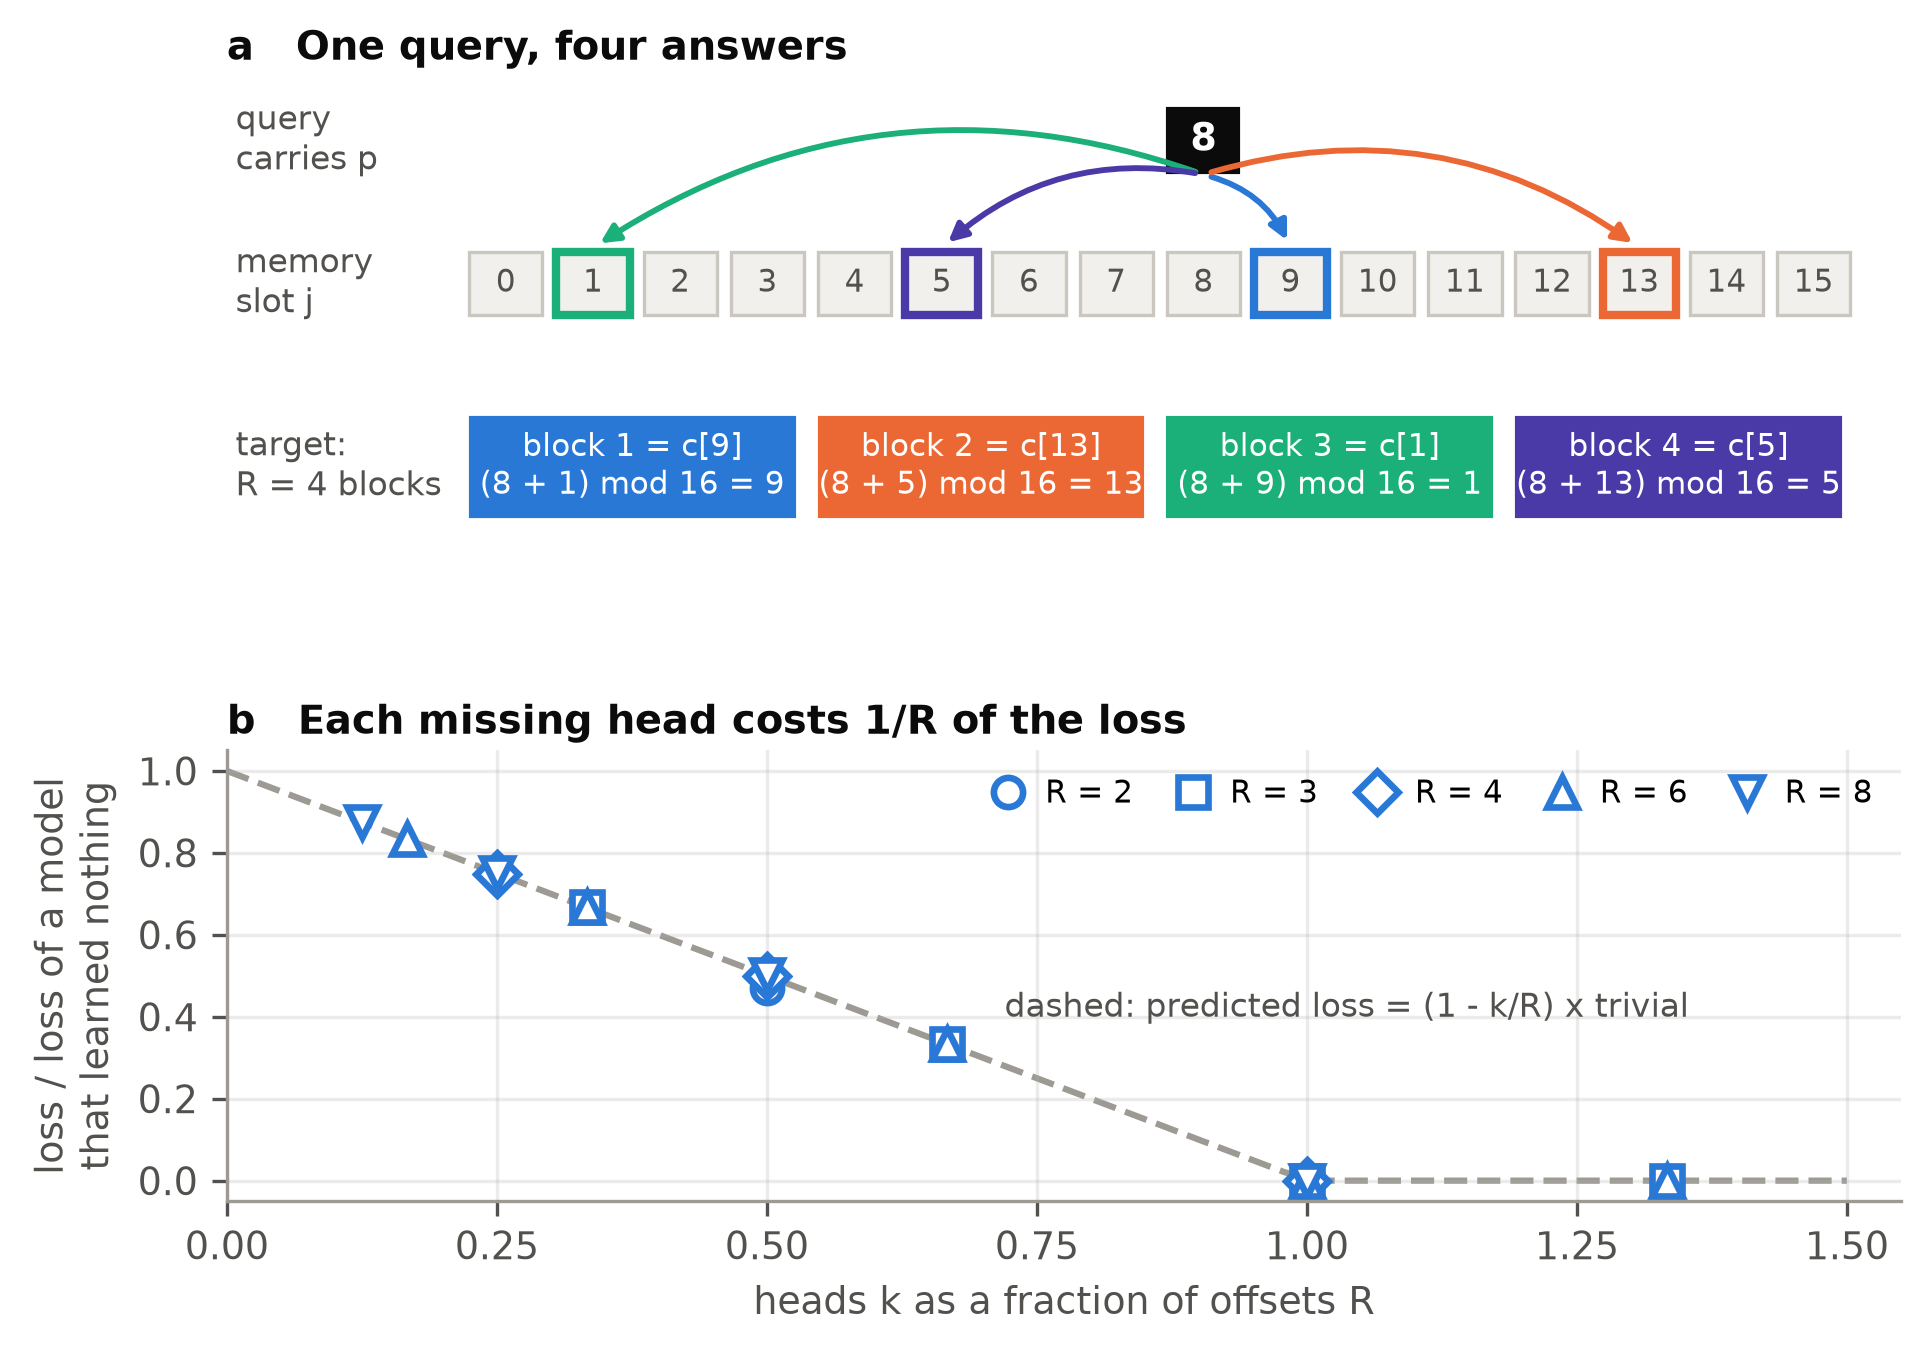

In [3]:
display(Image("../figures/thesis_fig1_task.png", width=760))

**Why 4 heads?** A head looks at the lockers and hands back **one blend** of what it saw.
Blends are equations. Two unknowns $x, y$ and one equation $x + y = 10$: stuck. Add
$x - y = 2$: now $x = 6$, $y = 4$. But $2x + 2y = 20$ would add nothing, because it is the
first equation again. The number of *different* equations is called the **rank**.

So $R$ unknown items need $R$ different blends: $k \ge R$ heads. With fewer, each missing
equation leaves one item unknown, and the loss is

$$L(k) = \Big(1 - \frac{k}{R}\Big) \times L_{\text{trivial}}, \qquad L_{\text{trivial}} = \text{loss of a model that learned nothing}.$$

**By hand** at $R = 4$: one head leaves $3/4$ of the trivial loss, two heads $2/4$, three
$1/4$, four heads 0.

**Experiment E1** tests this directly on a trained 4-head model: take heads away, or replace
a head with a **copy** of another, and let the output layer do its best with what is left.

trivial loss 1.0075

heads the model can use    different  measured  predicted
h1 + h2 + h3 + h4                  4    0.0000     0.0000
h1 + h2 + h3                       3    0.2540     0.2519
h1 + h3 + h4                       3    0.2537     0.2519
h1 + h2                            2    0.5073     0.5037
h3 + h4                            2    0.5068     0.5037
h2                                 1    0.7576     0.7556
h4                                 1    0.7586     0.7556
h1 + h1 + h3 + h4                  3    0.2537     0.2519
h1 + h2 + h2 + h2                  2    0.5073     0.5037


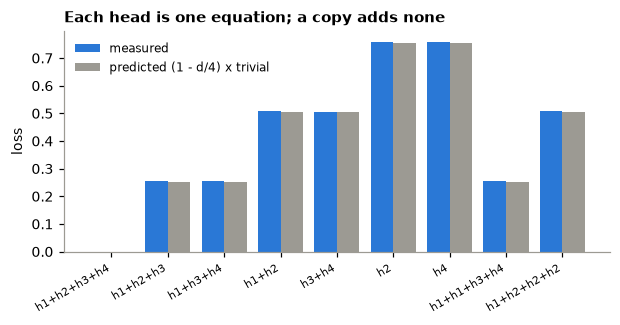

In [4]:
with open("../results/proposal/equations.pkl", "rb") as f:
    E1 = pickle.load(f)
print(f"trivial loss {E1['trivial']:.4f}\n")
print(f"{'heads the model can use':<26}{'different':>10}{'measured':>10}{'predicted':>11}")
for row in E1["rows"]:
    print(f"{row['name']:<26}{row['different']:>10}{row['loss']:>10.4f}{row['predicted']:>11.4f}")

fig, ax = plt.subplots(figsize=(6.4, 2.6))
x = np.arange(len(E1["rows"]))
ax.bar(x - 0.2, [r["loss"] for r in E1["rows"]], 0.4, color=BLUE, label="measured")
ax.bar(x + 0.2, [r["predicted"] for r in E1["rows"]], 0.4, color=GREY, label="predicted (1 - d/4) x trivial")
ax.set_xticks(x, [r["name"].replace(" + ", "+") for r in E1["rows"]], rotation=30, ha="right", fontsize=7.5)
ax.set_ylabel("loss")
ax.legend(fontsize=8)
ax.set_title("Each head is one equation; a copy adds none")
plt.show()

The last two rows are the key: **four heads where one is a copy behave exactly like three
heads.** The count that matters is the number of *different* equations. This also gives a
**redundancy meter** used in Aim 3: heads kept minus the number of different equations.

## 4. Which rules can count heads?

Each rule starts with all 32 heads on while the model learns, then moves the supply.

- **Fixed threshold**: feed heads that stand out from the others. Like grading on a curve,
  it hands out about the same number of places whatever the task.
- **Feedback loop + stall gate**: a thermostat on the loss. Too many mistakes, feed more
  heads; doing well, feed fewer. The gate waits while the model is still improving.
- **Pruning baseline** (Michel et al. 2019): remove the least important head until the loss
  breaks the bar, then put the last one back. The standard method.
- **Local rule**: every 25 steps, ask each head *what no other head can cover* (remove it,
  let the others re-fit, measure the loss rise). Close the cheapest if it is worth less than
  a price; heads fade out over 100 steps.
- **Local rule, no fixed total**: the same, but the supplies do not have to add up to 32.

The table gives heads kept for each task size, then: average miss in heads, runs that ended
solved, the worst loss after first being solved (below 1 = never fell back above the bar),
and compute (1 = one full dense training run).

rule                               2     3     4     6     8   <- heads kept, when the task needs k*
fixed threshold                  2.7   2.0   4.0   4.0   4.0   miss 1.53   solved  9/17  worst/bar  40.12   compute 0.60
feedback loop + stall gate       2.0   3.0   4.0   6.0   8.0   miss 0.00   solved 37/50  worst/bar  16.63   compute 0.42
pruning baseline                 2.0   3.0   4.0   6.0   8.7   miss 0.13   solved 15/15  worst/bar  18.34   compute 0.43
local rule                       3.7     -   4.3     -   8.0   miss 0.67   solved  9/9   worst/bar   0.57   compute 0.39
local rule, no fixed total       2.0     -   4.0     -   8.0   miss 0.00   solved  9/9   worst/bar   0.56   compute 0.37


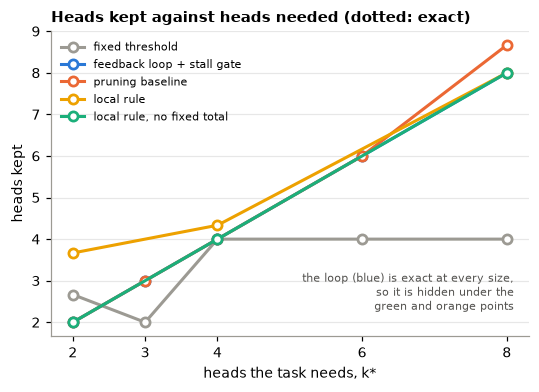

In [5]:
ARMS = {"fixed threshold": dict(supply="threshold"),
        "feedback loop + stall gate": dict(supply="autoreg", stall_gate=0.02),
        "pruning baseline": dict(supply="prune"),
        "local rule": BEST,
        "local rule, no fixed total": {**BEST, "conserve": 0}}
report(ARMS)

fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.plot([2, 8], [2, 8], ls=":", color=GREY, lw=1.2)
for (name, kw), color in zip(ARMS.items(), [GREY, BLUE, ORANGE, YELLOW, AQUA]):
    B = {k: np.mean(v) for k, v in by_size(pick(**kw)).items()}
    ax.plot(list(B), list(B.values()), "o-", color=color, lw=2, ms=6, mfc="white", mew=1.8, label=name)
ax.set(xlabel="heads the task needs, k*", ylabel="heads kept", xticks=[2, 3, 4, 6, 8])
ax.legend(fontsize=7.5, loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.text(8.1, 2.3, "the loop (blue) is exact at every size,\nso it is hidden under the\ngreen and orange points", fontsize=7.5, color=INK, ha="right")
ax.set_title("Heads kept against heads needed (dotted: exact)")
plt.show()

**Reading it.** The fixed threshold flattens at about 4 heads: it cannot count. Every rule
that looks at the loss counts correctly, *including the standard pruning baseline*, so
counting by itself is not what makes this work new. What separates the rules is the next
column: the loop and pruning jump far above the bar while removing heads; the local rules
never do.

## 5. Does each piece of biology earn its place? (experiment E3)

Take the local rule and remove one ingredient at a time, 3 seeds for each task size:

| control | removes | if the ingredient matters, expect |
|---|---|---|
| **no fixed total** | autoregulation (shares need not add to 32) | worse count or stability |
| **random pick** | collateral value, for *which* head to close (the timing is kept) | loses the task, wrong heads |
| **standard score** | collateral value, replaced by the usual "loss rise if removed, no re-fit" | keeps redundant heads |
| **no fade** | slow metabolic feedback (heads switched off at once) | loss jumps above the bar |

rule                               2     4     8   <- heads kept, when the task needs k*
local rule                       3.7   4.3   8.0   miss 0.67   solved  9/9   worst/bar   0.57   compute 0.39
no fixed total                   2.0   4.0   8.0   miss 0.00   solved  9/9   worst/bar   0.56   compute 0.37
random pick                      2.3   4.0   8.0   miss 0.11   solved  9/9   worst/bar   6.49   compute 0.38
standard score                   7.3   7.0  11.7   miss 4.00   solved  9/9   worst/bar   0.54   compute 0.48
no fade                          2.0   4.5   8.0   miss 0.17   solved  6/6   worst/bar  12.26   compute 0.36


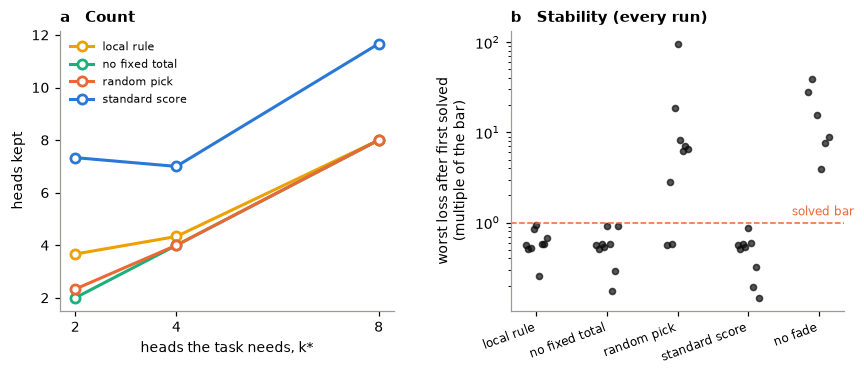

In [6]:
CONTROLS = {"local rule": BEST,
            "no fixed total": {**BEST, "conserve": 0},
            "random pick": {**BEST, "local_value": "random"},
            "standard score": {**BEST, "local_value": "ablate"},
            "no fade": {**BEST, "taper": 0}}
report(CONTROLS, sizes=(2, 4, 8))

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.3), gridspec_kw=dict(wspace=0.35))
ax = axes[0]
ax.plot([2, 8], [2, 8], ls=":", color=GREY, lw=1.2)
for (name, kw), color in zip(list(CONTROLS.items())[:4], [YELLOW, AQUA, ORANGE, BLUE]):
    B = {k: np.mean(v) for k, v in by_size(pick(**kw)).items()}
    ax.plot(list(B), list(B.values()), "o-", color=color, lw=2, ms=6, mfc="white", mew=1.8, label=name)
ax.set(xlabel="heads the task needs, k*", ylabel="heads kept", xticks=[2, 4, 8])
ax.legend(fontsize=7.5, loc="upper left")
ax.set_title("a   Count")
ax = axes[1]
names = list(CONTROLS)
for i, name in enumerate(names):
    w = [worst_after_solved(r) for r in pick(**CONTROLS[name])]
    ax.scatter(np.full(len(w), i) + np.linspace(-0.15, 0.15, len(w)), w, color=DARK, s=16, alpha=0.7)
ax.axhline(1, color=ORANGE, ls="--", lw=1)
ax.text(len(names) - 0.5, 1.2, "solved bar", color=ORANGE, fontsize=8, ha="right")
ax.set(yscale="log", ylabel="worst loss after first solved\n(multiple of the bar)")
ax.set_xticks(range(len(names)), names, rotation=20, ha="right", fontsize=8)
ax.set_title("b   Stability (every run)")
plt.show()

**Reading it, ingredient by ingredient.**

- **Collateral value earns its place, twice.** With a *random pick* the count is right (the
  rule still decides *when*), but runs fall far above the bar on the way, because the wrong
  heads get closed; they recover only by the end of training.
  With the *standard score* the model never falls back, but it keeps several heads too
  many, because a score that ignores the other heads cannot see that two heads do the same
  job.
- **Slow fading earns its place.** Without it, removing a head throws the loss above the bar.
- **The fixed total does not earn its place.** Without it the count is *exact* at every size,
  stability is unchanged, and compute is slightly lower. The autoregulation analogy is
  framing, and the thesis should say so.

## 6. Planted copies (experiment E4)

The cleanest test of "a head is worth what no other head can cover". Start training with
every head paired with an **exact copy** (head $h$ and head $h + 16$ identical). A copy can
always be covered by its twin, so the collateral rule should never keep both. A standard
score sees each copy doing half the work and has no reason to drop either.

In [7]:
print(f"{'value used':<16}{'seed':>5}{'heads kept':>12}{'twin pairs both kept':>22}{'solved':>8}")
counts = {}
for value in ["refit", "ablate"]:
    for r in sorted(pick(**BEST, n_rel=4, plant_copies=1, local_value=value), key=lambda r: setting(r, "seed")):
        on = r["hist"]["ledger"][-1] > 1e-9
        twins = sum(bool(on[h] and on[h + 16]) for h in range(16))
        counts.setdefault(value, []).append((int(on.sum()), twins))
        print(f"{'collateral' if value == 'refit' else 'standard score':<16}{setting(r, 'seed'):>5}"
              f"{int(on.sum()):>12}{twins:>22}{str(solved(r)):>8}")

value used       seed  heads kept  twin pairs both kept  solved
collateral          0           4                     0    True
collateral          1           4                     0    True
collateral          2           4                     0    True
standard score      0          12                     5    True
standard score      1          12                     5    True
standard score      2          15                     7    True


The collateral rule keeps exactly the 4 heads the task needs, with **no** pair of copies.
The standard score keeps 12 to 15 heads, including several pairs of copies. This is the
one-picture version of why "can the others cover for you?" is not the same as pruning by
importance.

## 7. Compute: one run against searching over sizes

Without this method, you would train a 1-head model, then 2, 4, ... until one solves the
task, then narrow down between the last two sizes. Section 3 shows a model solves exactly
when it has $k \ge k^\star$ heads, so the sizes tried are known in advance. Each try is a
full run of $k$ heads, costing $k/32$ of a dense run.

**By hand**, $k^\star = 4$: try 1 (fails), 2 (fails), 4 (solves), then 3 (fails), so the
answer is 4. Cost $(1 + 2 + 4 + 3)/32 = 0.31$.

In [8]:
def search_cost(kstar):
    tried, k = [], 1
    while True:
        tried.append(k)
        if k >= kstar:
            break
        k *= 2
    lo, hi = (tried[-2] if len(tried) > 1 else 0), tried[-1]
    while hi - lo > 1:                      # narrow down between the last failure and success
        mid = (lo + hi) // 2
        tried.append(mid)
        lo, hi = (lo, mid) if mid >= kstar else (mid, hi)
    return sum(tried) / 32, tried


print(f"{'k*':>3}{'search: sizes tried':>26}{'cost':>7}{'local rule':>12}{'no fixed total':>16}")
for R in (2, 4, 8):
    cost, tried = search_cost(R)
    local = np.mean([compute_used(r) for r in pick(**BEST, n_rel=R)])
    free = np.mean([compute_used(r) for r in pick(**BEST, conserve=0, n_rel=R)])
    print(f"{R:>3}{str(tried):>26}{cost:>7.2f}{local:>12.2f}{free:>16.2f}")

 k*       search: sizes tried   cost  local rule  no fixed total
  2                    [1, 2]   0.09        0.35            0.31
  4              [1, 2, 4, 3]   0.31        0.36            0.36
  8        [1, 2, 4, 8, 6, 7]   0.88        0.45            0.45


Searching is **cheaper for small circuits** and our single run is **cheaper for larger
ones**. So the efficiency claim is "cheaper when the circuit is large", not "cheaper". Two
further caveats: these are operation counts (the code still computes switched-off heads),
and each search try here is a full-length run.

## 8. A second task (experiment E2)

In **qsa_cross** the lockers are random each time and the question lists them ("bring the
average of lockers 3 and 11"). Here heads are interchangeable: more heads add capacity
rather than doing different jobs. The first tests reported "failed in every run", but the
target was out of reach even for the full model. So first, **E2a** measures the real answer
by training models of every size from scratch.

loss / trivial loss, dense models trained from scratch (6000 steps each)
 d_k       1       2       3       4       6       8      16      32
   2  0.8663  0.7748  0.5997  0.4692  0.3948  0.1914  0.0805  0.0374
   4  0.7711  0.4667  0.3832  0.3320  0.0035  0.0961  0.0475  0.0294
   8  0.4671  0.0050  0.0005  0.0002  0.0002  0.0010  0.0358  0.0221
  16  0.1986  0.0006  0.0003  0.0006  0.0017  0.0094  0.0218  0.0162


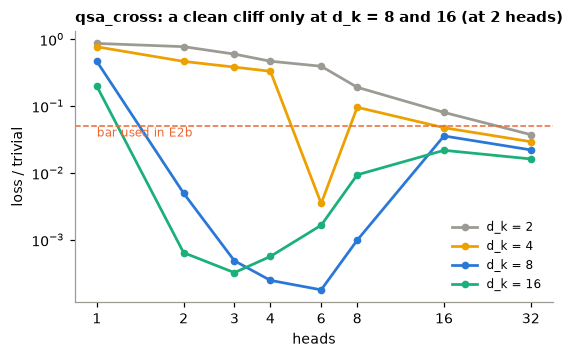

In [9]:
with open("../results/proposal/qsa_dense.pkl", "rb") as f:
    Q = pickle.load(f)
ks = [1, 2, 3, 4, 6, 8, 16, 32]
print("loss / trivial loss, dense models trained from scratch (6000 steps each)")
print(f"{'d_k':>4}" + "".join(f"{k:>8}" for k in ks))
for dk, v in Q.items():
    print(f"{dk:>4}" + "".join(f"{v['loss'][k] / v['trivial']:>8.4f}" for k in ks))

fig, ax = plt.subplots(figsize=(5.6, 3.2))
for (dk, v), color in zip(Q.items(), [GREY, YELLOW, BLUE, AQUA]):
    ax.plot(ks, [v["loss"][k] / v["trivial"] for k in ks], "o-", color=color, lw=1.8, ms=4, label=f"d_k = {dk}")
ax.axhline(0.05, color=ORANGE, ls="--", lw=1)
ax.text(1, 0.035, "bar used in E2b", color=ORANGE, fontsize=8, ha="left")
ax.set(xscale="log", yscale="log", xticks=ks, xticklabels=ks, xlabel="heads", ylabel="loss / trivial")
ax.minorticks_off()
ax.legend(fontsize=8)
ax.set_title("qsa_cross: a clean cliff only at d_k = 8 and 16 (at 2 heads)")
plt.show()

Two surprises: **bigger models train worse** on this task (32 heads end above 2 or 3 heads),
and a clean answer exists only at head width $d_k = 8$ and $16$, where it is **2 heads**.
The repo's formula for this task was also wrong.

**E2b, a fair re-test** at those two widths, with a bar the starting model can reach (5% of
the trivial loss). The right answer is 2.

In [10]:
print(f"{'d_k':>4} {'rule':<26}{'heads kept (2 seeds)':>22}{'solved':>8}{'compute':>9}")
names = {"autoreg": "feedback loop + stall gate", "prune": "pruning baseline", "local": "local rule"}
for dk in (8, 16):
    for sup in ("autoreg", "prune", "local"):
        rs = [r for r in QSA_FIX if setting(r, "d_k") == dk and setting(r, "supply") == sup]
        kept = [heads_kept(r) for r in sorted(rs, key=lambda r: setting(r, "seed"))]
        ok = sum(r["final_loss"] <= 0.05 * r["trivial"] for r in rs)
        print(f"{dk:>4} {names[sup]:<26}{str(kept):>22}{ok:>5}/{len(rs)}{np.mean([compute_used(r) for r in rs]):>9.2f}")

 d_k rule                        heads kept (2 seeds)  solved  compute
   8 feedback loop + stall gate          [29.0, 28.0]    2/2     0.96
   8 pruning baseline                    [26.0, 26.0]    2/2     0.86
   8 local rule                            [8.0, 8.0]    0/2     0.47
  16 feedback loop + stall gate          [22.0, 25.0]    2/2     0.92
  16 pruning baseline                    [25.0, 25.0]    2/2     0.84
  16 local rule                            [3.0, 3.0]    2/2     0.38


The loss-target rules barely remove anything: the 32-head model only just reaches the bar,
so every removal pushes it over. The local rule has no target and keeps **3 heads at
$d_k = 16$** (solved), but **8 at $d_k = 8$** (not solved). Half a success, two seeds: first
evidence beyond the main task, not a general result.

## 9. The proposal

### What the preliminary results support

| Claim | Evidence | Strength |
|---|---|---|
| the task needs exactly $R$ heads, and the loss of every smaller model is predicted | Section 3, E1 | strong |
| rules that only compare heads cannot count | Section 4 | strong |
| the collateral value is the working ingredient | Sections 5 and 6 | good, 3 seeds |
| slow fading keeps the model solved while heads are removed | Section 5 | good |
| the fixed total helps | Section 5 | **not supported** |
| cheaper than searching over sizes | Section 7 | only for larger circuits |
| works beyond the main task | Section 8 | weak, one setting |

### Aim 1. A benchmark with a known answer, and why (mostly done)

Write up the rank argument and E1. Replace the wrong qsa_cross formula with measured values.
*Would prove me wrong:* a model solving the task with fewer than $R$ different equations.

### Aim 2. The collateral rule: what no other head can cover

Make the result solid: 10 seeds, the price varied over 5 values (to show the price does not
secretly encode the answer), a 2-layer model on induction (a standard circuit that needs heads
in different layers to cooperate), wall-clock time with switched-off heads skipped, and the
closest baselines (constrained L0 gates, EarlyBERT).
*Would prove me wrong:* the standard score or random pick matching the collateral rule on
count *and* stability once seeds are added.

### Aim 3. Minimal or robust: when does a circuit keep backup heads?

Vascular network theory predicts that a network adapting to flow becomes a **tree** (no
spare routes) under steady demand, and keeps **loops** (spare routes) under damage or
fluctuating demand (Hu and Cai 2013; Katifori et al. 2010). Developing brain vessels do
prune low-flow loops (Chen et al. 2012). Transformers keep **backup heads** (the Hydra
effect), and why is an open question.

- *Prediction:* training with random head damage (dropout), or with demand that changes from
  batch to batch, makes the collateral rule keep backup heads; steady training does not.
- *Measure:* the redundancy meter from E1 (heads kept minus different equations), and the
  loss after knocking out one kept head.
- *Because the fixed total failed its control,* Aim 3 is about the dynamics, with no fixed
  total as the baseline. A budget with an exponent (the $\gamma$ of vessel cost laws) is
  tested as one candidate, not assumed.
- *Would prove me wrong:* redundancy that does not change with damage or fluctuation.

### Aim 4. A real model

GPT-2 small on the IOI task (tracking names through a sentence), which has known backup
heads: does the redundancy meter find them, and does damage during fine-tuning add more?

### Order of work

1. Aim 1 write-up (days). 2. Aim 2 seeds, price sweep and baselines (about 150 short GPU
runs). 3. Aim 3 on this task (about 60 runs), then induction. 4. Aim 4.

## 10. Reproduce everything

```bash
pytest -q tests/                                   # 9 tests, about 20 s
python experiments/equations_test.py               # E1  -> results/proposal/equations.pkl
python experiments/qsa_dense.py                    # E2a -> results/proposal/qsa_dense.pkl  (7 min)
cat results/qsa_fix/jobs.txt  | xargs -P 4 -L 1 bash results/qsa_fix/run_one.sh     # E2b
cat results/proposal/jobs.txt | xargs -P 5 -L 1 bash results/proposal/run_one.sh    # E3, E4
python experiments/build_proposal_notebook.py      # rebuild this notebook
jupyter nbconvert --to notebook --execute --inplace notebooks/thesis_proposal.ipynb
```

The controls are options of the local rule, off by default: `conserve=0`,
`local_value=ablate|random`, `plant_copies=1` (see `src/hemo/config.py`).